In [82]:
import numpy as np
import pandas as pd
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from pathlib import Path
from calculator import SeaIceCalc, Habitability, SST, SRD, Tempdiff, Tempdiffall

In [ ]:
file = "../earth/output.nc"
file2 = "../stability/run_0006/output2.nc"
file3 = "../stability/run_0.0005/output.nc"
file4 = "../stability/run_0.0001/output.nc"

In [84]:
ds = xr.open_dataset(file)
ds2 = xr.open_dataset(file2)
ds3 = xr.open_dataset(file3)
ds4 = xr.open_dataset(file4)

In [85]:
print(ds)

<xarray.Dataset> Size: 10GB
Dimensions:         (time: 7301, lon: 96, lat: 48, layer: 8, soil_layer: 2)
Coordinates:
  * time            (time) datetime64[ns] 58kB 2000-01-01 ... 2004-12-30
  * lon             (lon) float64 768B 0.0 3.75 7.5 11.25 ... 348.8 352.5 356.2
  * lat             (lat) float64 384B 87.16 83.48 79.78 ... -83.48 -87.16
  * layer           (layer) float32 32B 0.0625 0.1875 0.3125 ... 0.8125 0.9375
  * soil_layer      (soil_layer) int64 16B 1 2
Data variables: (12/28)
    rain_conv       (time, lat, lon) float32 135MB ...
    sru             (time, lat, lon) float32 135MB ...
    rain_cond       (time, lat, lon) float32 135MB ...
    lsm             (lat, lon) float32 18kB ...
    st              (time, soil_layer, lat, lon) float32 269MB ...
    tsurf           (time, lat, lon) float32 135MB ...
    ...              ...
    sst             (time, lat, lon) float32 135MB ...
    lru             (time, lat, lon) float32 135MB ...
    snow_cond       (time, lat, lon

In [86]:
year1 = ds.sel(time=slice("2000-01-01", "2000-12-31"))
year2 = ds.sel(time=slice("2001-01-01", "2001-12-31"))
year3 = ds.sel(time=slice("2002-01-01", "2002-12-31"))
year4 = ds.sel(time=slice("2003-01-01", "2003-12-31"))
year5 = ds.sel(time=slice("2004-01-01", "2004-12-31"))

year12 = ds2.sel(time=slice("2000-01-01", "2000-12-31"))
year22 = ds2.sel(time=slice("2001-01-01", "2001-12-31"))
year32 = ds2.sel(time=slice("2002-01-01", "2002-12-31"))
year42 = ds2.sel(time=slice("2003-01-01", "2003-12-31"))
year52 = ds2.sel(time=slice("2004-01-01", "2004-12-31"))

year13 = ds3.sel(time=slice("2000-01-01", "2000-12-31"))
year23 = ds3.sel(time=slice("2001-01-01", "2001-12-31"))
year33 = ds3.sel(time=slice("2002-01-01", "2002-12-31"))
year43 = ds3.sel(time=slice("2003-01-01", "2003-12-31"))
year53 = ds3.sel(time=slice("2004-01-01", "2004-12-31"))

year14 = ds4.sel(time=slice("2000-01-01", "2000-12-31"))
year24 = ds4.sel(time=slice("2001-01-01", "2001-12-31"))
year34 = ds4.sel(time=slice("2002-01-01", "2002-12-31"))
year44 = ds4.sel(time=slice("2003-01-01", "2003-12-31"))
year54 = ds4.sel(time=slice("2004-01-01", "2004-12-31"))

In [87]:
def sst_timeseries(ds):
    # SST
    sst = ds["sst"]

    # Ocean fraction
    ocean_frac = 1.0 - ds["lsm"]

    # Latitude weights
    lat = sst["lat"]
    weights = np.cos(np.deg2rad(lat))
    weights = weights.where(np.isfinite(weights), 0)
    weights_2d, _ = xr.broadcast(weights, sst)

    # Numerator: average sea surface temperature over the whole ocean
    num = (sst * ocean_frac * weights_2d).sum(dim=["lat", "lon"])

    # Denominator: total ocean area
    den = (ocean_frac * weights_2d).sum(dim=["lat", "lon"])

    # Avoid division by zero
    result = num / den.where(den != 0, np.nan)
    
    return result.values  # Return as numpy array


In [88]:
sst_year1 = sst_timeseries(year1)  # Array of SST at each timestep
sst_year2 = sst_timeseries(year2)
sst_year3 = sst_timeseries(year3)
sst_year4 = sst_timeseries(year4)
sst_year5 = sst_timeseries(year5)

sst2_year1 = sst_timeseries(year12)  # Array of SST at each timestep
sst2_year2 = sst_timeseries(year22)
sst2_year3 = sst_timeseries(year32)
sst2_year4 = sst_timeseries(year42)
sst2_year5 = sst_timeseries(year52)

sst3_year1 = sst_timeseries(year13)  # Array of SST at each timestep
sst3_year2 = sst_timeseries(year23)
sst3_year3 = sst_timeseries(year33)
sst3_year4 = sst_timeseries(year43)
sst3_year5 = sst_timeseries(year53)

sst4_year1 = sst_timeseries(year14)  # Array of SST at each timestep
sst4_year2 = sst_timeseries(year24)
sst4_year3 = sst_timeseries(year34)
sst4_year4 = sst_timeseries(year44)
sst4_year5 = sst_timeseries(year54)

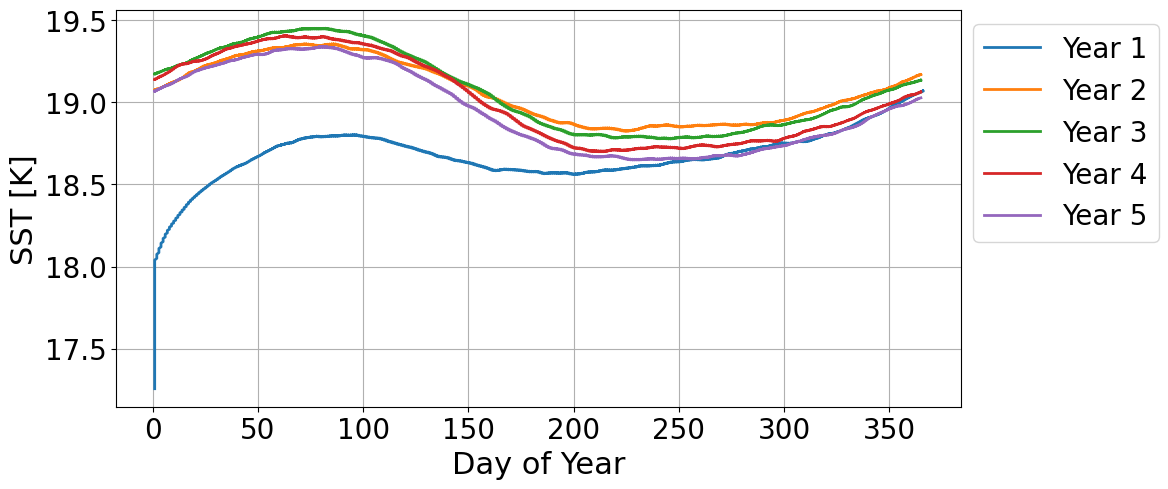

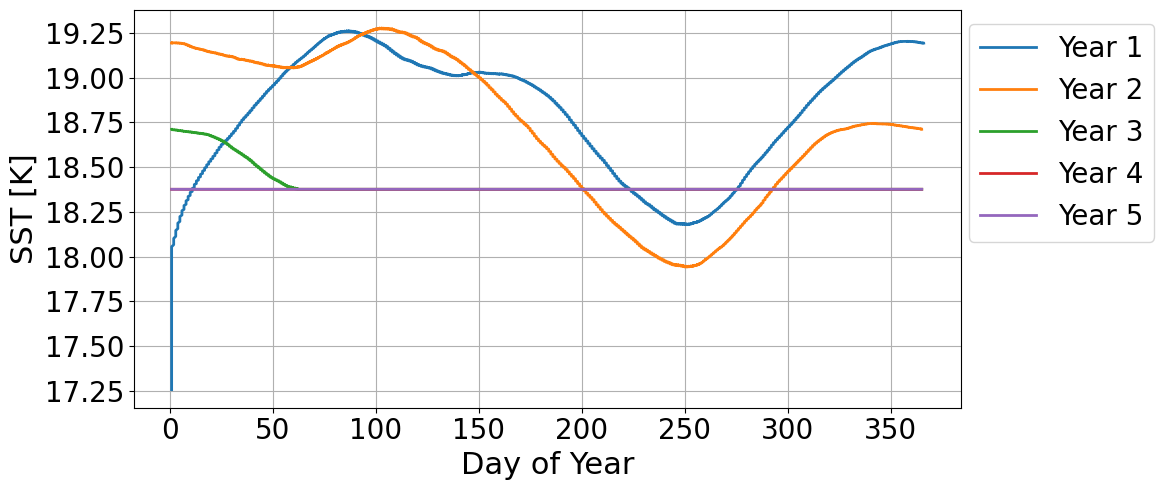

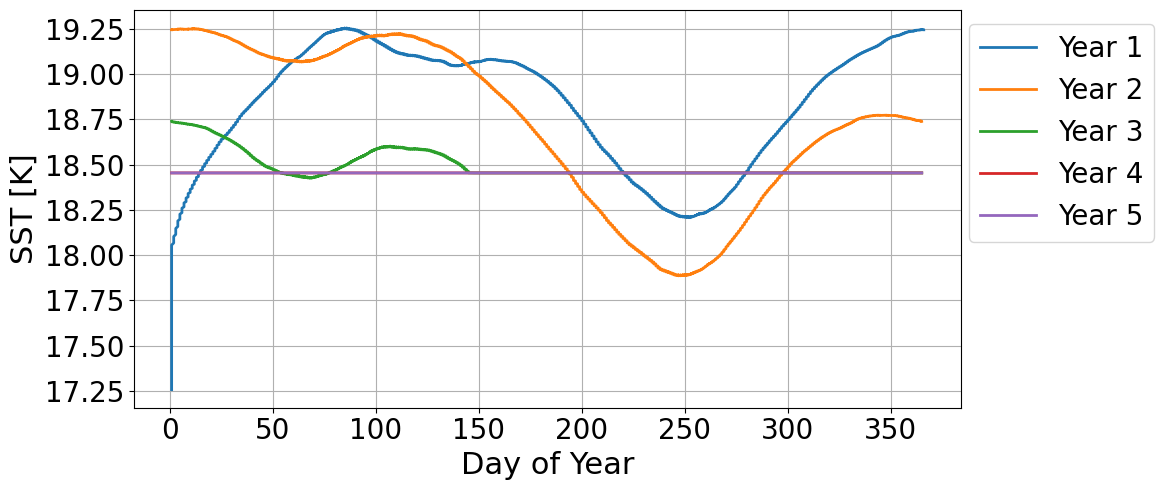

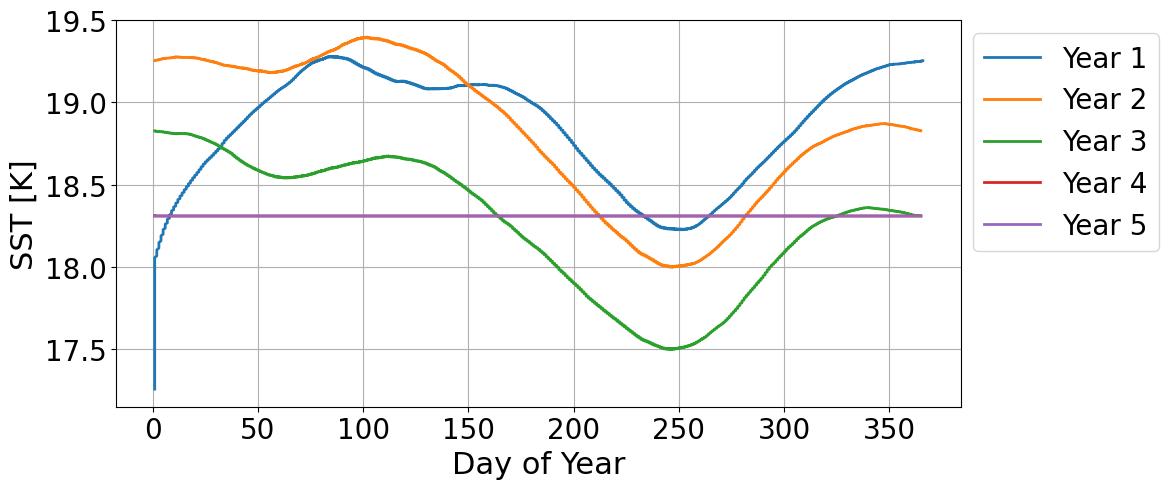

In [89]:
# Plot
plt.figure(figsize=(12, 5))

plt.plot(year1.time.dt.dayofyear.values, sst_year1, label="Year 1", linewidth=2)
plt.plot(year2.time.dt.dayofyear.values, sst_year2, label="Year 2", linewidth=2)
plt.plot(year3.time.dt.dayofyear.values, sst_year3, label="Year 3", linewidth=2)
plt.plot(year4.time.dt.dayofyear.values, sst_year4, label="Year 4", linewidth=2)
plt.plot(year5.time.dt.dayofyear.values, sst_year5, label="Year 5", linewidth=2)

plt.xlabel("Day of Year", size = 22)
plt.ylabel("SST [K]", size = 22)
# plt.ylim(18,19.5)
# plt.xlim(0,365)
plt.xticks(size=20)
plt.yticks(size=20)
plt.legend(fontsize=20, loc="upper right", bbox_to_anchor=(1.25, 1))
plt.grid()
plt.tight_layout()
plt.show()

# Plot
plt.figure(figsize=(12, 5))

plt.plot(year12.time.dt.dayofyear.values, sst2_year1, label="Year 1", linewidth=2)
plt.plot(year22.time.dt.dayofyear.values, sst2_year2, label="Year 2", linewidth=2)
plt.plot(year32.time.dt.dayofyear.values, sst2_year3, label="Year 3", linewidth=2)
plt.plot(year42.time.dt.dayofyear.values, sst2_year4, label="Year 4", linewidth=2)
plt.plot(year52.time.dt.dayofyear.values, sst2_year5, label="Year 5", linewidth=2)

plt.xlabel("Day of Year", size = 22)
plt.ylabel("SST [K]", size = 22)
# plt.ylim(18,19.5)
# plt.xlim(0,365)
plt.xticks(size=20)
plt.yticks(size=20)
plt.legend(fontsize=20, loc="upper right", bbox_to_anchor=(1.25, 1))
plt.grid()
plt.tight_layout()
plt.show()

# Plot
plt.figure(figsize=(12, 5))

plt.plot(year13.time.dt.dayofyear.values, sst3_year1, label="Year 1", linewidth=2)
plt.plot(year23.time.dt.dayofyear.values, sst3_year2, label="Year 2", linewidth=2)
plt.plot(year33.time.dt.dayofyear.values, sst3_year3, label="Year 3", linewidth=2)
plt.plot(year43.time.dt.dayofyear.values, sst3_year4, label="Year 4", linewidth=2)
plt.plot(year53.time.dt.dayofyear.values, sst3_year5, label="Year 5", linewidth=2)

plt.xlabel("Day of Year", size = 22)
plt.ylabel("SST [K]", size = 22)
# plt.ylim(18,19.5)
# plt.xlim(0,365)
plt.xticks(size=20)
plt.yticks(size=20)
plt.legend(fontsize=20, loc="upper right", bbox_to_anchor=(1.25, 1))
plt.grid()
plt.tight_layout()
plt.show()

# Plot
plt.figure(figsize=(12, 5))

plt.plot(year14.time.dt.dayofyear.values, sst4_year1, label="Year 1", linewidth=2)
plt.plot(year24.time.dt.dayofyear.values, sst4_year2, label="Year 2", linewidth=2)
plt.plot(year34.time.dt.dayofyear.values, sst4_year3, label="Year 3", linewidth=2)
plt.plot(year44.time.dt.dayofyear.values, sst4_year4, label="Year 4", linewidth=2)
plt.plot(year54.time.dt.dayofyear.values, sst4_year5, label="Year 5", linewidth=2)

plt.xlabel("Day of Year", size = 22)
plt.ylabel("SST [K]", size = 22)
# plt.ylim(18,19.5)
# plt.xlim(0,365)
plt.xticks(size=20)
plt.yticks(size=20)
plt.legend(fontsize=20, loc="upper right", bbox_to_anchor=(1.25, 1))
plt.grid()
plt.tight_layout()
plt.show()

In [90]:
def sic_timeseries(ds):
    sic = ds["sic"]

    # Mask ice to be over threshold to count towards ice coverage
    ice_present = sic >= 0.15

    # Ocean fraction
    ocean_frac = 1.0 - ds["lsm"]

    # Latitude weights
    lat = sic["lat"]
    weights = np.cos(np.deg2rad(lat))
    weights = weights.where(np.isfinite(weights), 0)
    weights_2d, _ = xr.broadcast(weights, sic)


    # Numerator: ice area over the ocean
    num = (ice_present * ocean_frac * weights_2d).sum(dim=["lat", "lon"])

    # Denominator: total ocean area
    den = (ocean_frac * weights_2d).sum(dim=["lat", "lon"])

    # Avoid division by zero
    result = num / den.where(den != 0, np.nan)
    
    return result.values  # Return as numpy array

In [91]:
sic_year1 = sic_timeseries(year1)  # Array of SIC at each timestep
sic_year2 = sic_timeseries(year2)
sic_year3 = sic_timeseries(year3)
sic_year4 = sic_timeseries(year4)
sic_year5 = sic_timeseries(year5)

sic2_year1 = sic_timeseries(year12)  # Array of SIC at each timestep
sic2_year2 = sic_timeseries(year22)
sic2_year3 = sic_timeseries(year32)
sic2_year4 = sic_timeseries(year42)
sic2_year5 = sic_timeseries(year52)

sic3_year1 = sic_timeseries(year13)  # Array of SIC at each timestep
sic3_year2 = sic_timeseries(year23)
sic3_year3 = sic_timeseries(year33)
sic3_year4 = sic_timeseries(year43)
sic3_year5 = sic_timeseries(year53)

sic4_year1 = sic_timeseries(year14)  # Array of SIC at each timestep
sic4_year2 = sic_timeseries(year24)
sic4_year3 = sic_timeseries(year34)
sic4_year4 = sic_timeseries(year44)
sic4_year5 = sic_timeseries(year54)

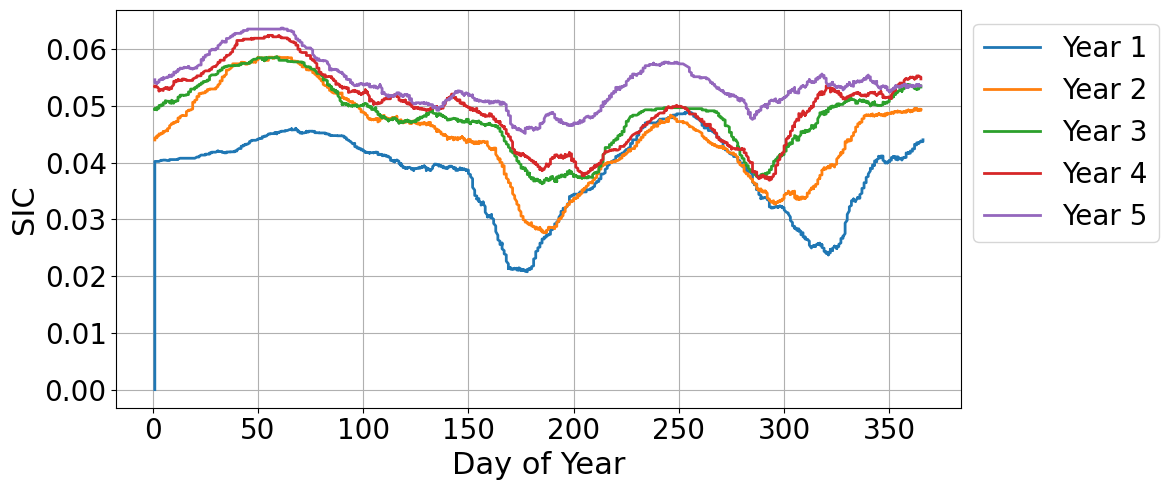

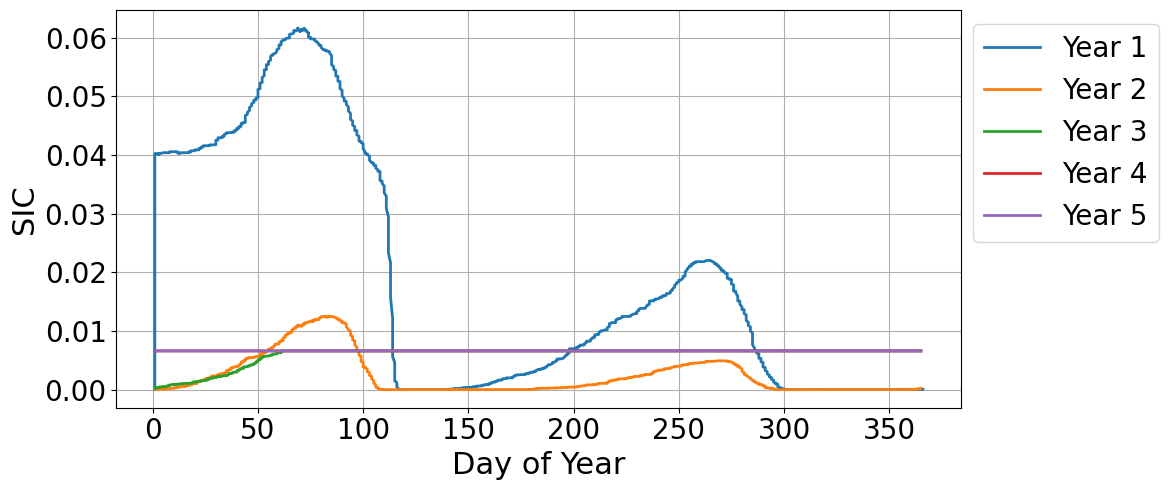

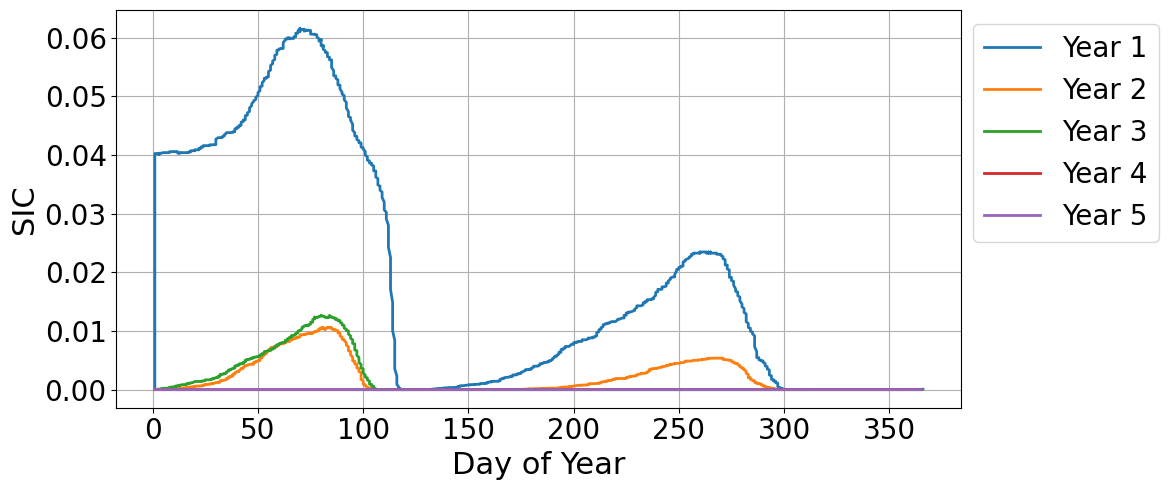

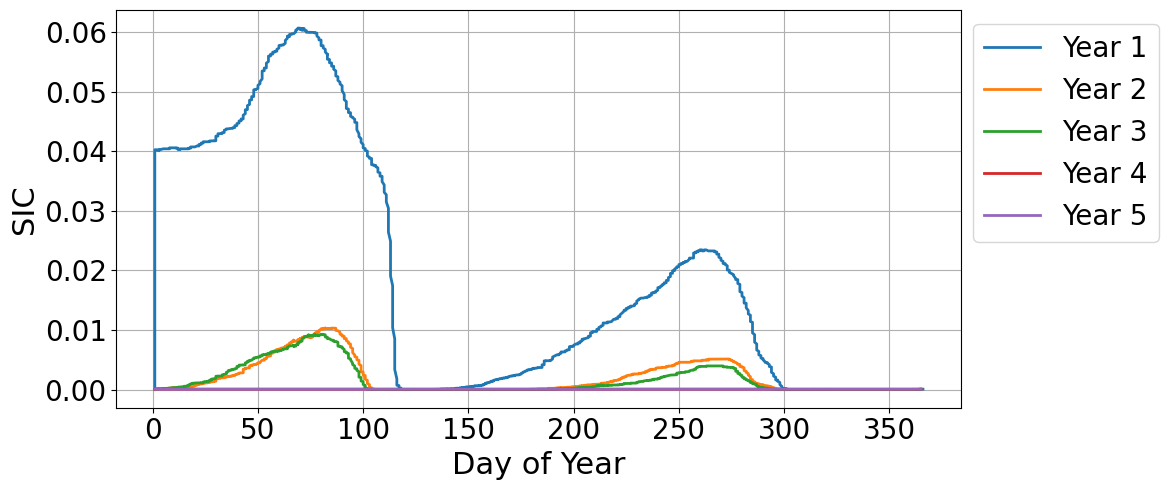

In [92]:
# Plot
plt.figure(figsize=(12, 5))

plt.plot(year1.time.dt.dayofyear.values, sic_year1, label="Year 1", linewidth=2)
plt.plot(year2.time.dt.dayofyear.values, sic_year2, label="Year 2", linewidth=2)
plt.plot(year3.time.dt.dayofyear.values, sic_year3, label="Year 3", linewidth=2)
plt.plot(year4.time.dt.dayofyear.values, sic_year4, label="Year 4", linewidth=2)
plt.plot(year5.time.dt.dayofyear.values, sic_year5, label="Year 5", linewidth=2)

plt.xlabel("Day of Year", size = 22)
plt.ylabel("SIC", size = 22)
# plt.ylim(0,0.07)
# plt.xlim(0,365)
plt.xticks(size=20)
plt.yticks(size=20)
plt.legend(fontsize=20, loc="upper right", bbox_to_anchor=(1.25, 1))
plt.grid()
plt.tight_layout()
plt.show()

# Plot
plt.figure(figsize=(12, 5))

plt.plot(year12.time.dt.dayofyear.values, sic2_year1, label="Year 1", linewidth=2)
plt.plot(year22.time.dt.dayofyear.values, sic2_year2, label="Year 2", linewidth=2)
plt.plot(year32.time.dt.dayofyear.values, sic2_year3, label="Year 3", linewidth=2)
plt.plot(year42.time.dt.dayofyear.values, sic2_year4, label="Year 4", linewidth=2)
plt.plot(year52.time.dt.dayofyear.values, sic2_year5, label="Year 5", linewidth=2)

plt.xlabel("Day of Year", size = 22)
plt.ylabel("SIC", size = 22)
# plt.ylim(0,0.07)
# plt.xlim(0,365)
plt.xticks(size=20)
plt.yticks(size=20)
plt.legend(fontsize=20, loc="upper right", bbox_to_anchor=(1.25, 1))
plt.grid()
plt.tight_layout()
plt.show()

# Plot
plt.figure(figsize=(12, 5))

plt.plot(year13.time.dt.dayofyear.values, sic3_year1, label="Year 1", linewidth=2)
plt.plot(year23.time.dt.dayofyear.values, sic3_year2, label="Year 2", linewidth=2)
plt.plot(year33.time.dt.dayofyear.values, sic3_year3, label="Year 3", linewidth=2)
plt.plot(year43.time.dt.dayofyear.values, sic3_year4, label="Year 4", linewidth=2)
plt.plot(year53.time.dt.dayofyear.values, sic3_year5, label="Year 5", linewidth=2)

plt.xlabel("Day of Year", size = 22)
plt.ylabel("SIC", size = 22)
# plt.ylim(0,0.07)
# plt.xlim(0,365)
plt.xticks(size=20)
plt.yticks(size=20)
plt.legend(fontsize=20, loc="upper right", bbox_to_anchor=(1.25, 1))
plt.grid()
plt.tight_layout()
plt.show()

# Plot
plt.figure(figsize=(12, 5))

plt.plot(year14.time.dt.dayofyear.values, sic4_year1, label="Year 1", linewidth=2)
plt.plot(year24.time.dt.dayofyear.values, sic4_year2, label="Year 2", linewidth=2)
plt.plot(year34.time.dt.dayofyear.values, sic4_year3, label="Year 3", linewidth=2)
plt.plot(year44.time.dt.dayofyear.values, sic4_year4, label="Year 4", linewidth=2)
plt.plot(year54.time.dt.dayofyear.values, sic4_year5, label="Year 5", linewidth=2)

plt.xlabel("Day of Year", size = 22)
plt.ylabel("SIC", size = 22)
# plt.ylim(0,0.07)
# plt.xlim(0,365)
plt.xticks(size=20)
plt.yticks(size=20)
plt.legend(fontsize=20, loc="upper right", bbox_to_anchor=(1.25, 1))
plt.grid()
plt.tight_layout()
plt.show()

In [93]:
def st_timeseries(ds):
    st = ds["st"].isel(soil_layer=0)

    # Land mask
    land = ds["lsm"]

    # Latitude weights
    lat = st["lat"]
    weights = np.cos(np.deg2rad(lat))
    weights = weights.where(np.isfinite(weights), 0)
    weights_2d, _ = xr.broadcast(weights, st)

    # Numerator: ice area over the ocean
    num = (st * land * weights_2d).sum(dim=["lat", "lon"])

    # Denominator: total ocean area
    den = (st * weights_2d).sum(dim=["lat", "lon"])

    # Avoid division by zero
    result = num / den.where(den != 0, np.nan)
    
    return result.values  # Return as numpy array

In [94]:
st_year1 = st_timeseries(year1)  # Array of SIC at each timestep
st_year2 = st_timeseries(year2)
st_year3 = st_timeseries(year3)
st_year4 = st_timeseries(year4)
st_year5 = st_timeseries(year5)

st2_year1 = st_timeseries(year12)  # Array of SIC at each timestep
st2_year2 = st_timeseries(year22)
st2_year3 = st_timeseries(year32)
st2_year4 = st_timeseries(year42)
st2_year5 = st_timeseries(year52)

st3_year1 = st_timeseries(year13)  # Array of SIC at each timestep
st3_year2 = st_timeseries(year23)
st3_year3 = st_timeseries(year33)
st3_year4 = st_timeseries(year43)
st3_year5 = st_timeseries(year53)

st4_year1 = st_timeseries(year14)  # Array of SIC at each timestep
st4_year2 = st_timeseries(year24)
st4_year3 = st_timeseries(year34)
st4_year4 = st_timeseries(year44)
st4_year5 = st_timeseries(year54)

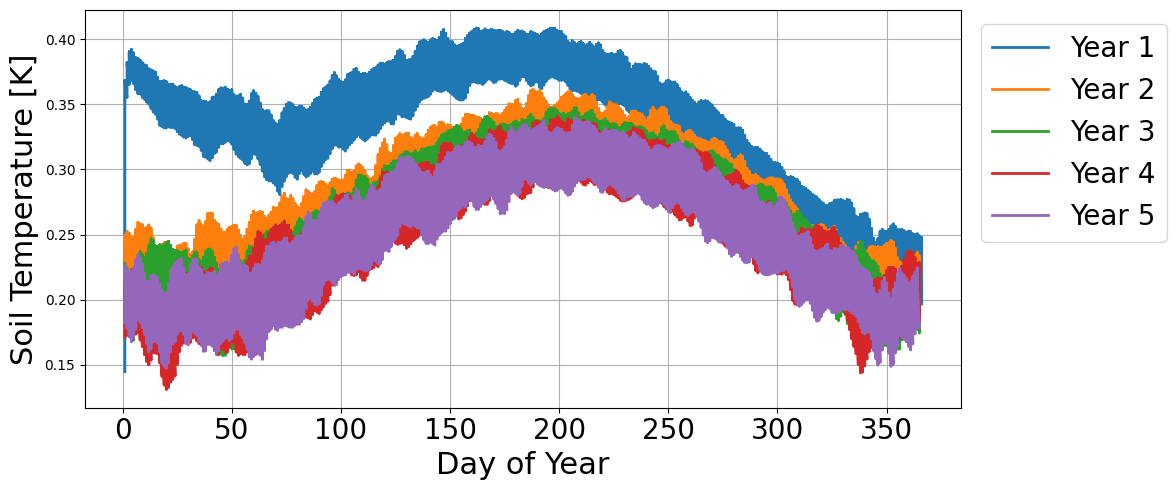

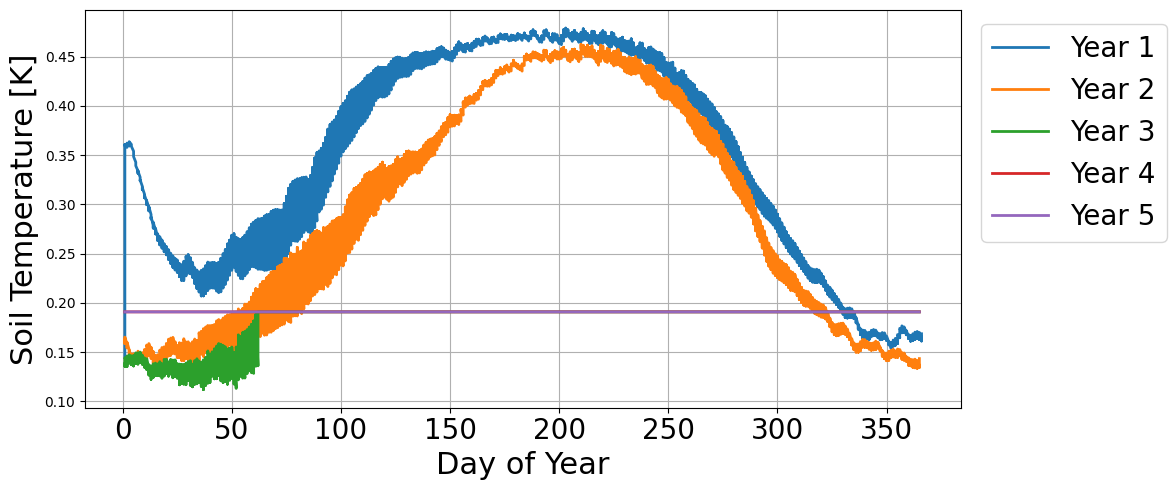

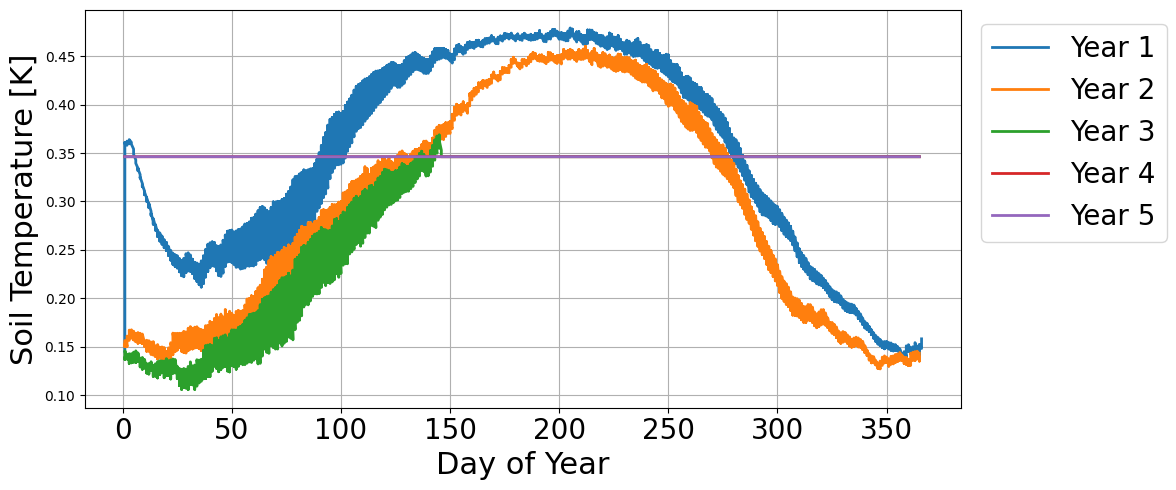

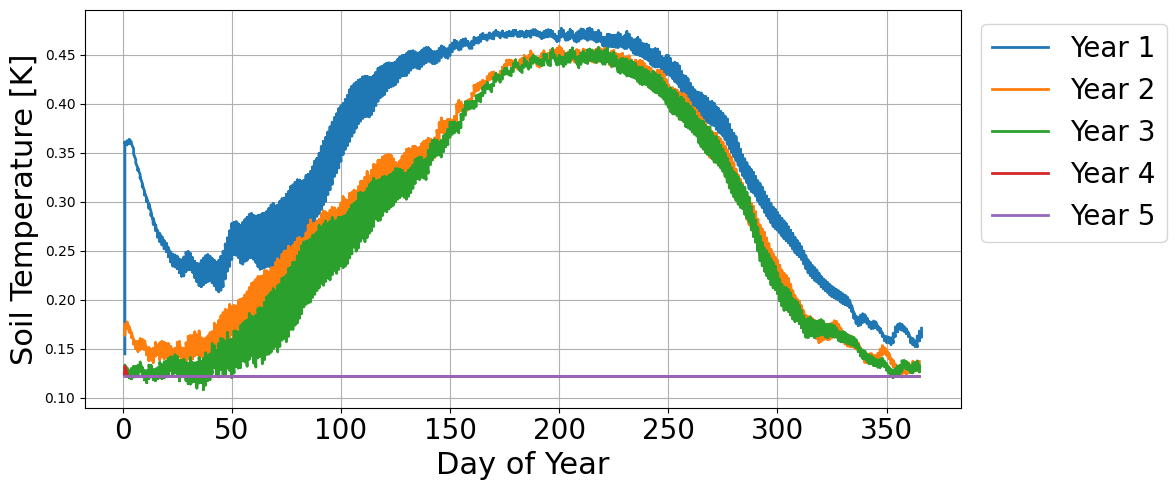

In [95]:
# Plot
plt.figure(figsize=(12, 5))

plt.plot(year1.time.dt.dayofyear.values, st_year1, label="Year 1", linewidth=2)
plt.plot(year2.time.dt.dayofyear.values, st_year2, label="Year 2", linewidth=2)
plt.plot(year3.time.dt.dayofyear.values, st_year3, label="Year 3", linewidth=2)
plt.plot(year4.time.dt.dayofyear.values, st_year4, label="Year 4", linewidth=2)
plt.plot(year5.time.dt.dayofyear.values, st_year5, label="Year 5", linewidth=2)

plt.xlabel("Day of Year", size = 22)
plt.ylabel("Soil Temperature [K]", size = 22)
# plt.ylim(18,19.5)
# plt.xlim(0,365)
plt.xticks(size=20)
# plt.yticks([18,18.25,18.5,18.75,19,19.25,19.5],size=20)
plt.legend(fontsize=20, loc="upper right", bbox_to_anchor=(1.25, 1))
plt.grid()
plt.tight_layout()
plt.show()

# Plot
plt.figure(figsize=(12, 5))

plt.plot(year12.time.dt.dayofyear.values, st2_year1, label="Year 1", linewidth=2)
plt.plot(year22.time.dt.dayofyear.values, st2_year2, label="Year 2", linewidth=2)
plt.plot(year32.time.dt.dayofyear.values, st2_year3, label="Year 3", linewidth=2)
plt.plot(year42.time.dt.dayofyear.values, st2_year4, label="Year 4", linewidth=2)
plt.plot(year52.time.dt.dayofyear.values, st2_year5, label="Year 5", linewidth=2)

plt.xlabel("Day of Year", size = 22)
plt.ylabel("Soil Temperature [K]", size = 22)
# plt.ylim(18,19.5)
# plt.xlim(0,365)
plt.xticks(size=20)
# plt.yticks([18,18.25,18.5,18.75,19,19.25,19.5],size=20)
plt.legend(fontsize=20, loc="upper right", bbox_to_anchor=(1.25, 1))
plt.grid()
plt.tight_layout()
plt.show()

# Plot
plt.figure(figsize=(12, 5))

plt.plot(year13.time.dt.dayofyear.values, st3_year1, label="Year 1", linewidth=2)
plt.plot(year23.time.dt.dayofyear.values, st3_year2, label="Year 2", linewidth=2)
plt.plot(year33.time.dt.dayofyear.values, st3_year3, label="Year 3", linewidth=2)
plt.plot(year43.time.dt.dayofyear.values, st3_year4, label="Year 4", linewidth=2)
plt.plot(year53.time.dt.dayofyear.values, st3_year5, label="Year 5", linewidth=2)

plt.xlabel("Day of Year", size = 22)
plt.ylabel("Soil Temperature [K]", size = 22)
# plt.ylim(18,19.5)
# plt.xlim(0,365)
plt.xticks(size=20)
# plt.yticks([18,18.25,18.5,18.75,19,19.25,19.5],size=20)
plt.legend(fontsize=20, loc="upper right", bbox_to_anchor=(1.25, 1))
plt.grid()
plt.tight_layout()
plt.show()

# Plot
plt.figure(figsize=(12, 5))

plt.plot(year14.time.dt.dayofyear.values, st4_year1, label="Year 1", linewidth=2)
plt.plot(year24.time.dt.dayofyear.values, st4_year2, label="Year 2", linewidth=2)
plt.plot(year34.time.dt.dayofyear.values, st4_year3, label="Year 3", linewidth=2)
plt.plot(year44.time.dt.dayofyear.values, st4_year4, label="Year 4", linewidth=2)
plt.plot(year54.time.dt.dayofyear.values, st4_year5, label="Year 5", linewidth=2)

plt.xlabel("Day of Year", size = 22)
plt.ylabel("Soil Temperature [K]", size = 22)
# plt.ylim(18,19.5)
# plt.xlim(0,365)
plt.xticks(size=20)
# plt.yticks([18,18.25,18.5,18.75,19,19.25,19.5],size=20)
plt.legend(fontsize=20, loc="upper right", bbox_to_anchor=(1.25, 1))
plt.grid()
plt.tight_layout()
plt.show()

In [96]:
def tsurf_timeseries(ds):
    tsurf = ds["tsurf"]

    # Latitude weights
    lat = tsurf["lat"]
    weights = np.cos(np.deg2rad(lat))
    weights = weights.where(np.isfinite(weights), 0)
    weights_2d, _ = xr.broadcast(weights, tsurf)

    # Numerator: ice area over the ocean
    num = (tsurf * weights_2d).sum(dim=["lat", "lon"])

    # Denominator: total ocean area
    den = (weights_2d).sum(dim=["lat", "lon"])

    # Avoid division by zero
    result = num / den.where(den != 0, np.nan)
    
    return result.values  # Return as numpy array

In [97]:
tsurf2_year1 = tsurf_timeseries(year12)  # Array of SIC at each timestep
tsurf2_year2 = tsurf_timeseries(year22)
tsurf2_year3 = tsurf_timeseries(year32)
tsurf2_year4 = tsurf_timeseries(year42)
tsurf2_year5 = tsurf_timeseries(year52)

tsurf_year1 = tsurf_timeseries(year1)  # Array of SIC at each timestep
tsurf_year2 = tsurf_timeseries(year2)
tsurf_year3 = tsurf_timeseries(year3)
tsurf_year4 = tsurf_timeseries(year4)
tsurf_year5 = tsurf_timeseries(year5)

tsurf3_year1 = tsurf_timeseries(year13)  # Array of SIC at each timestep
tsurf3_year2 = tsurf_timeseries(year23)
tsurf3_year3 = tsurf_timeseries(year33)
tsurf3_year4 = tsurf_timeseries(year43)
tsurf3_year5 = tsurf_timeseries(year53)

tsurf4_year1 = tsurf_timeseries(year14)  # Array of SIC at each timestep
tsurf4_year2 = tsurf_timeseries(year24)
tsurf4_year3 = tsurf_timeseries(year34)
tsurf4_year4 = tsurf_timeseries(year44)
tsurf4_year5 = tsurf_timeseries(year54)

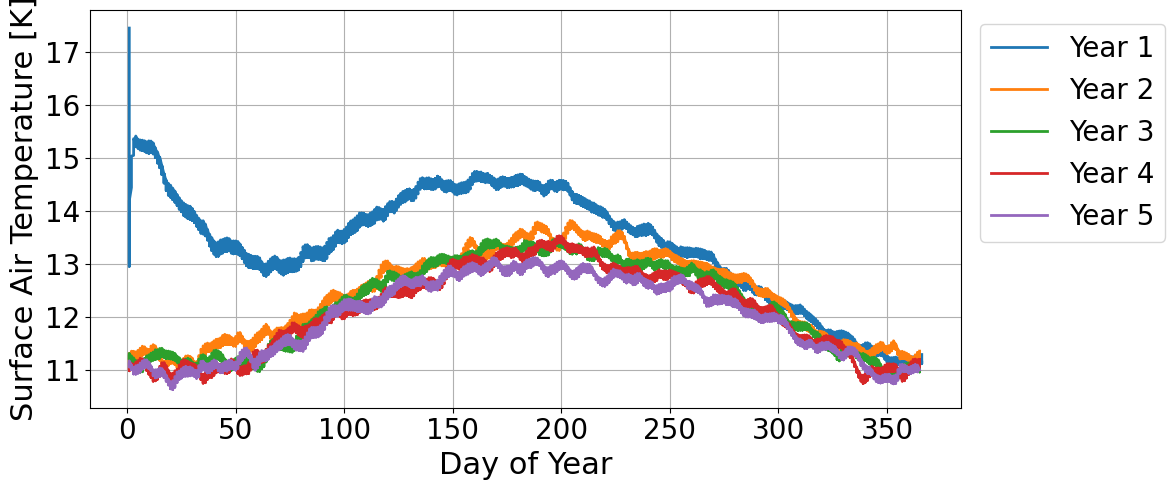

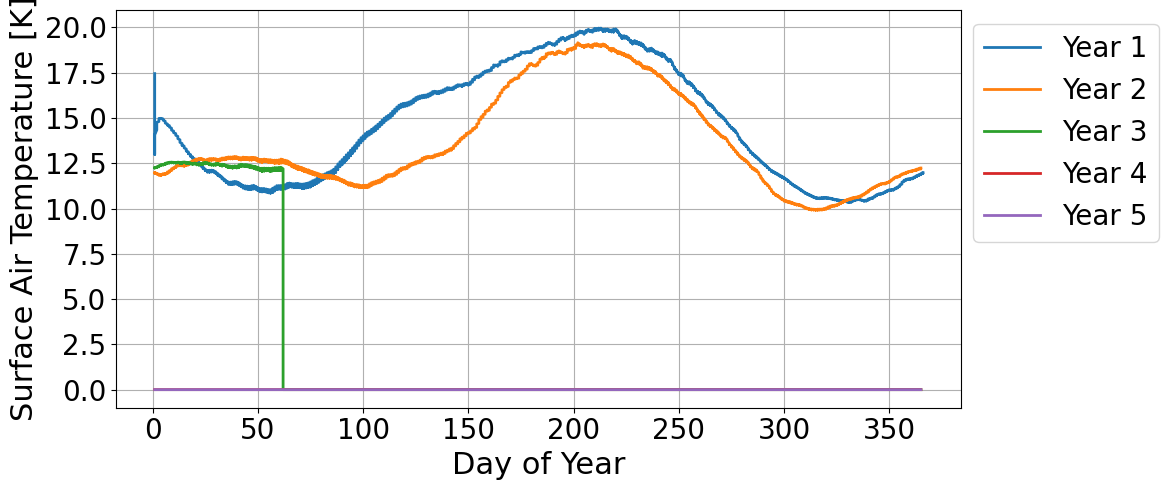

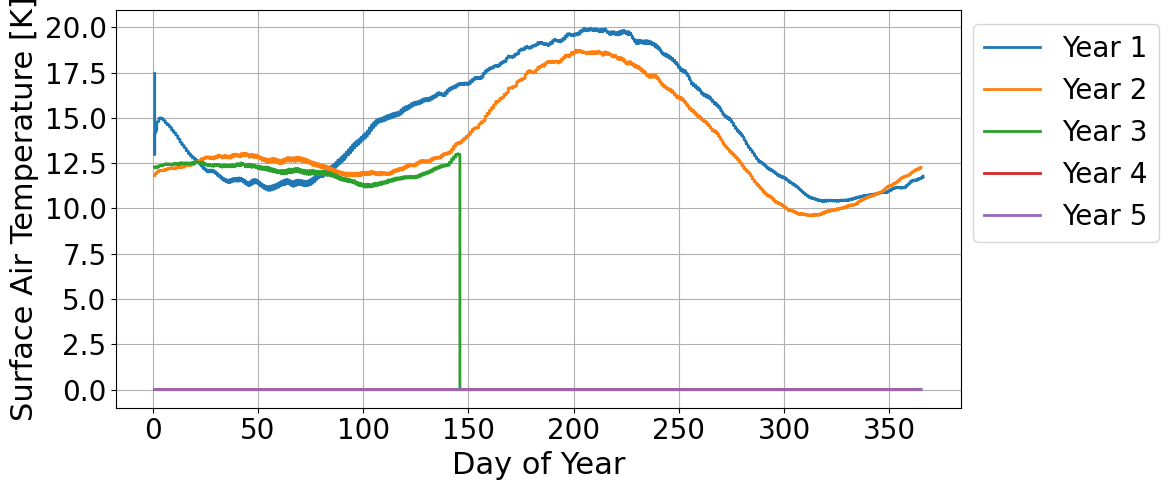

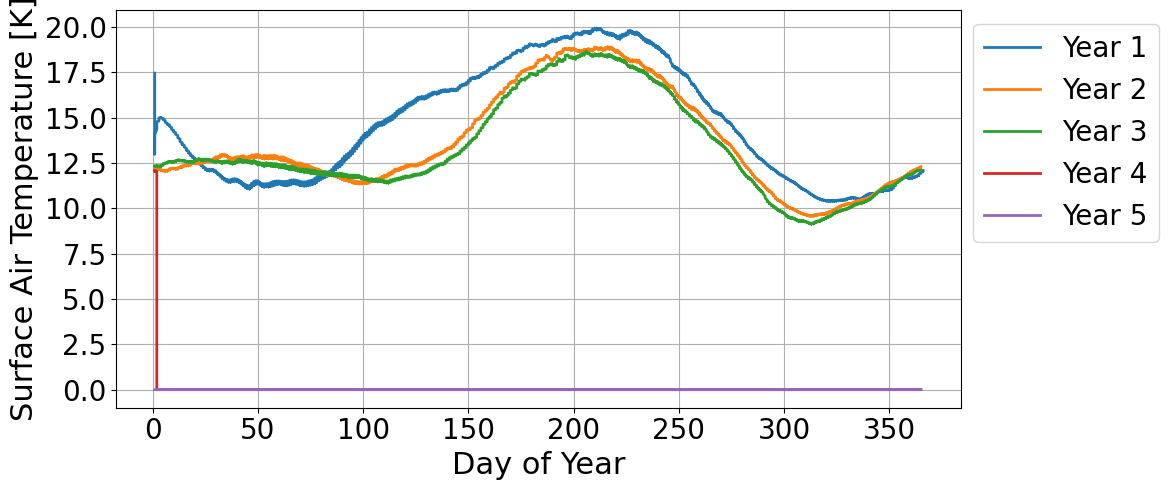

In [98]:
# Plot
plt.figure(figsize=(12, 5))

plt.plot(year1.time.dt.dayofyear.values, tsurf_year1, label="Year 1", linewidth=2)
plt.plot(year2.time.dt.dayofyear.values, tsurf_year2, label="Year 2", linewidth=2)
plt.plot(year3.time.dt.dayofyear.values, tsurf_year3, label="Year 3", linewidth=2)
plt.plot(year4.time.dt.dayofyear.values, tsurf_year4, label="Year 4", linewidth=2)
plt.plot(year5.time.dt.dayofyear.values, tsurf_year5, label="Year 5", linewidth=2)

plt.xlabel("Day of Year", size = 22)
plt.ylabel("Surface Air Temperature [K]", size = 22)
# plt.ylim(10,16)
# plt.xlim(0,365)
plt.xticks(size=20)
plt.yticks(size=20)
plt.legend(fontsize=20, loc="upper right", bbox_to_anchor=(1.25, 1))
plt.grid()
plt.tight_layout()
plt.show()

# Plot
plt.figure(figsize=(12, 5))

plt.plot(year12.time.dt.dayofyear.values, tsurf2_year1, label="Year 1", linewidth=2)
plt.plot(year22.time.dt.dayofyear.values, tsurf2_year2, label="Year 2", linewidth=2)
plt.plot(year32.time.dt.dayofyear.values, tsurf2_year3, label="Year 3", linewidth=2)
plt.plot(year42.time.dt.dayofyear.values, tsurf2_year4, label="Year 4", linewidth=2)
plt.plot(year52.time.dt.dayofyear.values, tsurf2_year5, label="Year 5", linewidth=2)

plt.xlabel("Day of Year", size = 22)
plt.ylabel("Surface Air Temperature [K]", size = 22)
# plt.ylim(10,16)
# plt.xlim(0,365)
plt.xticks(size=20)
plt.yticks(size=20)
plt.legend(fontsize=20, loc="upper right", bbox_to_anchor=(1.25, 1))
plt.grid()
plt.tight_layout()
plt.show()


# Plot
plt.figure(figsize=(12, 5))

plt.plot(year13.time.dt.dayofyear.values, tsurf3_year1, label="Year 1", linewidth=2)
plt.plot(year23.time.dt.dayofyear.values, tsurf3_year2, label="Year 2", linewidth=2)
plt.plot(year33.time.dt.dayofyear.values, tsurf3_year3, label="Year 3", linewidth=2)
plt.plot(year43.time.dt.dayofyear.values, tsurf3_year4, label="Year 4", linewidth=2)
plt.plot(year53.time.dt.dayofyear.values, tsurf3_year5, label="Year 5", linewidth=2)

plt.xlabel("Day of Year", size = 22)
plt.ylabel("Surface Air Temperature [K]", size = 22)
# plt.ylim(10,16)
# plt.xlim(0,365)
plt.xticks(size=20)
plt.yticks(size=20)
plt.legend(fontsize=20, loc="upper right", bbox_to_anchor=(1.25, 1))
plt.grid()
plt.tight_layout()
plt.show()


# Plot
plt.figure(figsize=(12, 5))

plt.plot(year14.time.dt.dayofyear.values, tsurf4_year1, label="Year 1", linewidth=2)
plt.plot(year24.time.dt.dayofyear.values, tsurf4_year2, label="Year 2", linewidth=2)
plt.plot(year34.time.dt.dayofyear.values, tsurf4_year3, label="Year 3", linewidth=2)
plt.plot(year44.time.dt.dayofyear.values, tsurf4_year4, label="Year 4", linewidth=2)
plt.plot(year54.time.dt.dayofyear.values, tsurf4_year5, label="Year 5", linewidth=2)

plt.xlabel("Day of Year", size = 22)
plt.ylabel("Surface Air Temperature [K]", size = 22)
# plt.ylim(10,16)
# plt.xlim(0,365)
plt.xticks(size=20)
plt.yticks(size=20)
plt.legend(fontsize=20, loc="upper right", bbox_to_anchor=(1.25, 1))
plt.grid()
plt.tight_layout()
plt.show()